In [211]:
import yfinance as yf
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D

In [212]:
class Config:
    #---------------------------------------------------------------------------
    # 1. 기본 백테스팅 환경
    #---------------------------------------------------------------------------

    QUANT_DATA_PATH = "momentum+earnings_260104.csv"
    START_DATE = "2016-01-01"  # 백테스트 시작일
    END_DATE = "2026-01-01"    # 백테스트 종료일
    FEES = 0.00015             # 거래 수수료

    #---------------------------------------------------------------------------
    # 2. 카나리아 (Market Signal) 설정
    #---------------------------------------------------------------------------

    # 카나리아 자산 리스트
    #CANARY_ASSETS = ['GLD', 'TLT', 'SPY', 'DX-Y.NYB']
    CANARY_ASSETS = ['QQQ', 'SMH', 'ACWI', 'CPER']

    # 카나리아 생존 판단 기준 (이동평균선)
    # 예: 200 -> 200일 이평선보다 가격이 높으면 '생존'
    CANARY_MA_PERIOD = 120

    # 리밸런싱 주기 (카나리아 확인 및 자산 교체 주기)
    # 'ME': 매월, 'QE': 분기별, '6ME': 반년
    REBALANCING_FREQ = 'ME'

    #---------------------------------------------------------------------------
    # 3. 자산 배분 비율 (Dynamic Asset Allocation)
    #---------------------------------------------------------------------------

    # 카나리아 생존 마릿수(key)에 따른 [공격자산 : 방어자산] 비중 설정
    # 현재 n=4 기준
    ALLOCATION_RULE = {
        4: {'attack': 1.0, 'defense': 0.0},  # 4마리 생존: 공격 100%
        3: {'attack': 0.75, 'defense': 0.25},
        2: {'attack': 0.50, 'defense': 0.50},
        1: {'attack': 0.25, 'defense': 0.75},
        0: {'attack': 0.0, 'defense': 1.0}   # 전멸: 수비 100%
    }

    #---------------------------------------------------------------------------
    # 4. 공격 자산
    #---------------------------------------------------------------------------
    TOP_N_SELECT = 30     # 최종 선정할 종목 개수 (상위 30개)
    WEIGHTING_SCHEME = 'equal' # 'equal'(동일비중 1/N) 또는 'score'(점수비중)

    #---------------------------------------------------------------------------
    # 5. 방어 자산 (Defensive) 운용 전략
    #---------------------------------------------------------------------------

    DEFENSIVE_ASSETS = ['SHY', 'GLD', 'DBC']

    # 방어 자산 내부 비중
    DEFENSIVE_WEIGHTING = 'equal'

In [213]:
def get_universe_from_csv():
    print(f"\n[1] 포트폴리오 파일 로드 중... ({Config.QUANT_DATA_PATH})")

    try:
        df = pd.read_csv(Config.QUANT_DATA_PATH)
        df.columns = df.columns.str.strip() # 컬럼 공백 제거
    except FileNotFoundError:
        print(f"파일을 찾을 수 없습니다: {Config.QUANT_DATA_PATH}")
        return {}

    # 상위 N개 자르기
    target_n = Config.TOP_N_SELECT
    if len(df) > target_n:
        print(f"   -> 전체 {len(df)}개 중 상위 {target_n}개 종목만 선택합니다.")
        df = df.head(target_n)
    else:
        print(f"   -> 종목 수가 {target_n}개보다 적어 전체를 사용합니다.")

    # 티커 변환 로직 (종목코드 -> 005930.KS)
    result_dict = {}

    # 가능한 컬럼명 후보
    code_cols = ['code', 'Code', '종목코드', '코드', 'Ticker']
    market_cols = ['market', 'Market', '시장', '시장구분', 'market_type']

    found_code = next((c for c in code_cols if c in df.columns), None)
    found_market = next((c for c in market_cols if c in df.columns), None)

    if not found_code:
        print("CSV 파일에 '종목코드' 컬럼이 없습니다.")
        return {}

    for idx, row in df.iterrows():
        # 1) 코드 6자리 맞춤
        raw_code = str(row[found_code]).replace('A', '').strip()
        code = raw_code.zfill(6)

        # 2) 시장 구분 (.KS / .KQ)
        suffix = ".KS"
        if found_market:
            mkt_str = str(row[found_market]).upper()
            if 'KQ' in mkt_str or 'KOSDAQ' in mkt_str or '코스닥' in mkt_str:
                suffix = ".KQ"

        yahoo_ticker = code + suffix
        result_dict[yahoo_ticker] = 1.0 # 동일 비중

    print(f"   -> 최종 유니버스 확정: {len(result_dict)}종목")
    return result_dict

In [214]:
def get_historical_canary_signals():
    print(f"\n[2] 카나리아 신호 생성 중... {Config.CANARY_ASSETS}")

    # 2016년 신호를 위해 1년 전 데이터부터 확보
    start_dt = pd.to_datetime(Config.START_DATE) - pd.Timedelta(days=365)
    tickers = Config.CANARY_ASSETS

    try:
        raw_df = yf.download(tickers, start=start_dt, end=Config.END_DATE, auto_adjust=True, progress=False)

        # 'Close' 컬럼 안전하게 추출
        if isinstance(raw_df.columns, pd.MultiIndex):
            df = raw_df.xs('Close', axis=1, level=0)
        else:
            df = raw_df['Close']

        # 타임존 제거 (필수)
        df.index = df.index.tz_localize(None)
        df = df.ffill()

    except Exception as e:
        print(f"카나리아 데이터 다운로드 실패: {e}")
        return None

    # 신호 계산: 가격 > 이동평균선 = 1(생존), 아니면 0(사망)
    ma_df = df.rolling(window=Config.CANARY_MA_PERIOD).mean()
    is_alive = (df > ma_df).astype(int)

    # 4개 자산 점수 합산 (0 ~ 4점)
    signal_series = is_alive.sum(axis=1)

    # 백테스트 기간에 맞춰 자르기
    signal_series = signal_series.loc[:Config.END_DATE]

    print(f"   -> 신호 생성 완료 (기간: {len(signal_series)}일)")
    return signal_series

In [215]:
def calculate_aggressive_strategy(target_dict):
    target_tickers = list(target_dict.keys())
    print(f"\n[3] 공격 자산(Top {len(target_tickers)}) 수익률 계산 중...")

    try:
        raw_df = yf.download(target_tickers, start=Config.START_DATE, end=Config.END_DATE, auto_adjust=True, progress=False)

        if isinstance(raw_df.columns, pd.MultiIndex):
            price_df = raw_df.xs('Close', axis=1, level=0)
        else:
            price_df = raw_df['Close']

        price_df.index = price_df.index.tz_localize(None)

        # [핵심] 데이터가 없는(신규상장 등) 종목 자동 제거
        failed_tickers = price_df.columns[price_df.isna().all()].tolist()
        if failed_tickers:
            print(f"[제외] 데이터 부족 종목 ({len(failed_tickers)}개): {failed_tickers}")
            price_df = price_df.drop(columns=failed_tickers)

        price_df = price_df.ffill()

    except Exception as e:
        print(f"공격 자산 데이터 오류: {e}")
        return pd.Series()

    if price_df.empty:
        print("유효한 공격 자산 데이터가 없습니다.")
        return pd.Series()

    # 일별 수익률 계산
    daily_ret = price_df.pct_change(fill_method=None).fillna(0)

    # 동일 비중(1/N)으로 합산
    port_ret = daily_ret.mean(axis=1)

    total_r = (1+port_ret).cumprod().iloc[-1] - 1
    print(f"   -> 공격 포트폴리오 누적 수익률: {total_r*100:,.2f}%")
    return port_ret

In [216]:
def calculate_defensive_strategy():
    tickers = Config.DEFENSIVE_ASSETS
    print(f"\n[3] 방어 자산 포트폴리오 계산 중... (대상: {tickers})")

    # 1. 데이터 다운로드
    try:
        # 방어 자산은 대부분 미국 ETF이므로 티커 변환 없이 그대로 사용
        raw_df = yf.download(tickers,
                             start=Config.START_DATE,
                             end=Config.END_DATE,
                             auto_adjust=True,
                             progress=False)

        # 'Close'만 추출 (단일 종목일 경우 Series, 다중 종목일 경우 DataFrame 반환)
        if len(tickers) == 1:
            price_df = raw_df['Close'].to_frame() # DataFrame으로 변환
            price_df.columns = tickers
        else:
            price_df = raw_df['Close']

        # 결측치 보정 (휴장일 등)
        price_df = price_df.ffill()

    except Exception as e:
        print(f"방어 자산 데이터 다운로드 실패: {e}")
        return pd.Series()

    # 2. 일별 수익률 계산
    daily_ret = price_df.pct_change(fill_method=None).fillna(0)

    # 3. 비중 적용 (Weighting)
    # 요청사항: 스코어링 로직이 들어와도 일단은 동일 비중으로 처리
    if Config.DEFENSIVE_WEIGHTING == 'score':
        print(" (알림) 방어 자산 스코어링 로직은 미정이므로, '동일 비중(1/N)'으로 계산합니다.")
        port_ret = daily_ret.mean(axis=1)

    else:
        # 'equal' (기본값)
        # mean(axis=1)은 N개 자산 수익률의 평균을 구함 (즉, 1/N 투자와 동일)
        print(f"[Equal Weighting] {len(tickers)}개 자산 동일 비중 적용")
        port_ret = daily_ret.mean(axis=1)

    # 4. 성과 미리보기
    cum_ret = (1 + port_ret).cumprod()

    if not cum_ret.empty:
        total_return = (cum_ret.iloc[-1] - 1) * 100
        print(f"   -> 방어 전략 누적 수익률: {total_return:,.2f}%")
    else:
        print("데이터가 없어 수익률을 계산할 수 없습니다.")

    return port_ret

In [217]:
def run_backtest(agg_ret, def_ret, canary_signals):
    print(f"\n[4] 백테스팅 시뮬레이션 가동... (주기: {Config.REBALANCING_FREQ})")

    # 1. 데이터 날짜 정렬 (Intersection)
    # 세 가지 데이터(공격, 수비, 신호)의 공통 기간만 추출
    combined = pd.concat([agg_ret, def_ret], axis=1).dropna()
    combined.columns = ['agg_ret', 'def_ret']

    # 2. 리밸런싱 시점의 목표 비중(Target Weight) 계산
    # 2-1. 리밸런싱 주기(예: 분기말)로 신호 데이터 샘플링
    rebal_signals = canary_signals.resample(Config.REBALANCING_FREQ).last()

    # 2-2. 신호(0~4)를 공격 자산 비중(0.0~1.0)으로 변환
    # 예: 신호 4 -> 공격 100%, 신호 0 -> 공격 0%
    # map 함수를 써서 ALLOCATION_RULE의 dict 값을 적용
    # ALLOCATION_RULE 구조: {4: {'attack': 1.0, ...}} 이므로 'attack' 값만 뽑아야 함
    rule_map = {k: v['attack'] for k, v in Config.ALLOCATION_RULE.items()}
    target_weights = rebal_signals.map(rule_map)

    # 2-3. 일별 데이터로 다시 늘리기 (Forward Fill)
    # 분기 초에 정해진 비중은 다음 분기 리밸런싱 전까지 유지됨
    daily_weights = target_weights.reindex(combined.index, method='ffill')

    # 2-4. 비중 적용 시점 조정 (Shift)
    daily_weights = daily_weights.shift(1).fillna(0)

    # 3. 포트폴리오 수익률 계산
    # 포트폴리오 수익률 = (공격비중 * 공격수익률) + ((1-공격비중) * 방어수익률)
    portfolio_ret = (daily_weights * combined['agg_ret']) + ((1 - daily_weights) * combined['def_ret'])

    # 4. 거래 수수료 반영 (Turnover)
    # 비중이 변하는 날을 찾아 수수료 부과
    # 수수료 차감 (비중이 변할 때만 발생)
    turnover = daily_weights.diff().abs().fillna(0)
    net_ret = port_ret - (turnover * Config.FEES)

    return net_ret, daily_weights

In [218]:
def evaluate_performance(daily_ret):
    wealth = (1 + daily_ret).cumprod()

    # 주요 지표 계산
    total_ret = wealth.iloc[-1] - 1
    days = (wealth.index[-1] - wealth.index[0]).days
    cagr = (wealth.iloc[-1]) ** (365.25 / days) - 1 if days > 0 else 0

    # MDD 계산
    rolling_max = wealth.cummax()
    drawdown = (wealth / rolling_max) - 1
    mdd = drawdown.min()

    # 샤프 지수 (무위험이자율 0 가정)
    sharpe = (daily_ret.mean() * 252) / (daily_ret.std() * np.sqrt(252))

    print("-" * 40)
    print(f" 전략 최종 성과 리포트")
    print("-" * 40)
    print(f"   1. 누적 수익률 : {total_ret*100:,.2f}%")
    print(f"   2. 연평균 수익 (CAGR) : {cagr*100:.2f}%")
    print(f"   3. 최대 낙폭 (MDD) : {mdd*100:.2f}%")
    print(f"   4. 샤프 지수 : {sharpe:.2f}")
    print("-" * 40)
    return wealth

In [219]:
def plot_canary_visualization(daily_ret, canary_signals):
    """
    KOSPI 지수의 누적 수익률 곡선을 그리고,
    배경 색상(선 색상)으로 우리 전략의 포지션(공격/방어)을 표시합니다.
    (차원 오류 수정됨)
    """
    print("\n[Visual] KOSPI 지수 대비 카나리아 신호 시각화 중...")

    # --------------------------------------------------------------------------
    # 1. KOSPI 데이터 다운로드
    # --------------------------------------------------------------------------
    try:
        # KOSPI 티커: ^KS11
        kospi_raw = yf.download("^KS11",
                                start=Config.START_DATE,
                                end=Config.END_DATE,
                                progress=False,
                                auto_adjust=True)

        # [수정] yfinance 최신 버전 대응 (MultiIndex 처리)
        # 'Close' 컬럼을 안전하게 가져와서 1차원 Series로 만듭니다.
        if isinstance(kospi_raw.columns, pd.MultiIndex):
            kospi_data = kospi_raw.xs('Close', axis=1, level=0)
        elif 'Close' in kospi_raw.columns:
            kospi_data = kospi_raw['Close']
        else:
            kospi_data = kospi_raw

        # 데이터프레임(1열)이라면 시리즈로 변환
        if isinstance(kospi_data, pd.DataFrame):
            kospi_data = kospi_data.iloc[:, 0]

        # [중요] Timezone 제거
        kospi_data.index = kospi_data.index.tz_localize(None)

        # 수익률 계산
        kospi_daily_ret = kospi_data.pct_change().fillna(0)

        # 누적 수익률 (Wealth Index)
        cum_return = (1 + kospi_daily_ret).cumprod()

    except Exception as e:
        print(f"KOSPI 데이터 다운로드 실패 ({e}). 전략 수익률로 대체합니다.")
        cum_return = (1 + daily_ret).cumprod()

    # --------------------------------------------------------------------------
    # 2. 신호 데이터 정렬
    # --------------------------------------------------------------------------

    # 1) 주기별 마지막 신호 추출
    rebal_signals = canary_signals.resample(Config.REBALANCING_FREQ).last()

    # 2) 신호 적용 시점 Shift
    effective_signals = rebal_signals.shift(1)

    # 3) KOSPI 날짜에 맞춰 신호 늘리기
    aligned_signal = effective_signals.reindex(cum_return.index).ffill().fillna(0)

    # --------------------------------------------------------------------------
    # 3. 그래프 그리기 (LineCollection)
    # --------------------------------------------------------------------------
    x = np.arange(len(cum_return))

    # [핵심 수정] y 데이터를 강제로 1차원 배열로 펼침 (flatten)
    # yfinance가 (N, 1) 형태의 DataFrame을 줄 경우를 대비해 .flatten() 추가
    y = cum_return.values.flatten()

    # 점들을 연결하여 선분 생성
    # 이제 x와 y가 모두 완벽한 1차원 배열이므로 에러가 나지 않습니다.
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # 색상 매핑
    color_map = {
        4: 'forestgreen',  # 공격 100%
        3: 'limegreen',    # 공격 75%
        2: 'gold',         # 중립 50%
        1: 'orange',       # 방어 75%
        0: 'red'           # 방어 100%
    }

    # 각 구간의 색상 결정
    colors = [color_map.get(int(s), 'grey') for s in aligned_signal.values.flatten()[:-1]]

    # 컬렉션 생성
    lc = LineCollection(segments, colors=colors, linewidths=2.0)

    fig, ax = plt.subplots(figsize=(14, 7))
    ax.add_collection(lc)

    # --------------------------------------------------------------------------
    # 4. 축 및 스타일 설정
    # --------------------------------------------------------------------------
    ax.set_xlim(0, len(cum_return))

    # y축 범위 설정 (데이터가 1차원이어야 min/max 계산이 정확함)
    y_min, y_max = y.min(), y.max()
    ax.set_ylim(y_min * 0.90, y_max * 1.10)

    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())

    # X축 날짜 포맷팅
    def format_date(x, pos=None):
        idx = int(x)
        if 0 <= idx < len(cum_return):
            return cum_return.index[idx].strftime('%Y-%m')
        return ''

    ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_date))
    ax.xaxis.set_major_locator(mticker.MaxNLocator(10))

    # 범례
    custom_lines = [
        Line2D([0], [0], color='forestgreen', lw=4),
        Line2D([0], [0], color='limegreen', lw=4),
        Line2D([0], [0], color='gold', lw=4),
        Line2D([0], [0], color='orange', lw=4),
        Line2D([0], [0], color='red', lw=4)
    ]
    ax.legend(custom_lines,
              ['Strong Attack (4)', 'Attack (3)', 'Neutral (2)', 'Defense (1)', 'Crisis Mode (0)'],
              loc='upper left', fontsize=10, frameon=True, shadow=True)

    # 타이틀
    total_ret = (cum_return.iloc[-1] - 1) * 100
    plt.title(f'KOSPI Index with Strategy Signals (Total: {total_ret:.1f}%)', fontsize=16, fontweight='bold')
    plt.grid(True, alpha=0.3, which='both')
    plt.ylabel('KOSPI Index Value (Log Scale)')

    plt.tight_layout()
    plt.show()


전략 백테스트

[1] 포트폴리오 파일 로드 중... (momentum+earnings_260104.csv)
   -> 전체 99개 중 상위 30개 종목만 선택합니다.
   -> 최종 유니버스 확정: 30종목

[3] 공격 자산(Top 30) 수익률 계산 중...
   -> 공격 포트폴리오 누적 수익률: 933.57%

[3] 방어 자산 포트폴리오 계산 중... (대상: ['SHY', 'GLD', 'DBC'])
[Equal Weighting] 3개 자산 동일 비중 적용
   -> 방어 전략 누적 수익률: 119.57%

[2] 카나리아 신호 생성 중... ['GLD', 'TLT', 'SPY', 'DX-Y.NYB']
   -> 신호 생성 완료 (기간: 2769일)

[4] 백테스팅 시뮬레이션 가동... (주기: ME)
----------------------------------------
 전략 최종 성과 리포트
----------------------------------------
   1. 누적 수익률 : 506.48%
   2. 연평균 수익 (CAGR) : 19.78%
   3. 최대 낙폭 (MDD) : -46.19%
   4. 샤프 지수 : 1.19
----------------------------------------

[Visual] KOSPI 지수 대비 카나리아 신호 시각화 중...


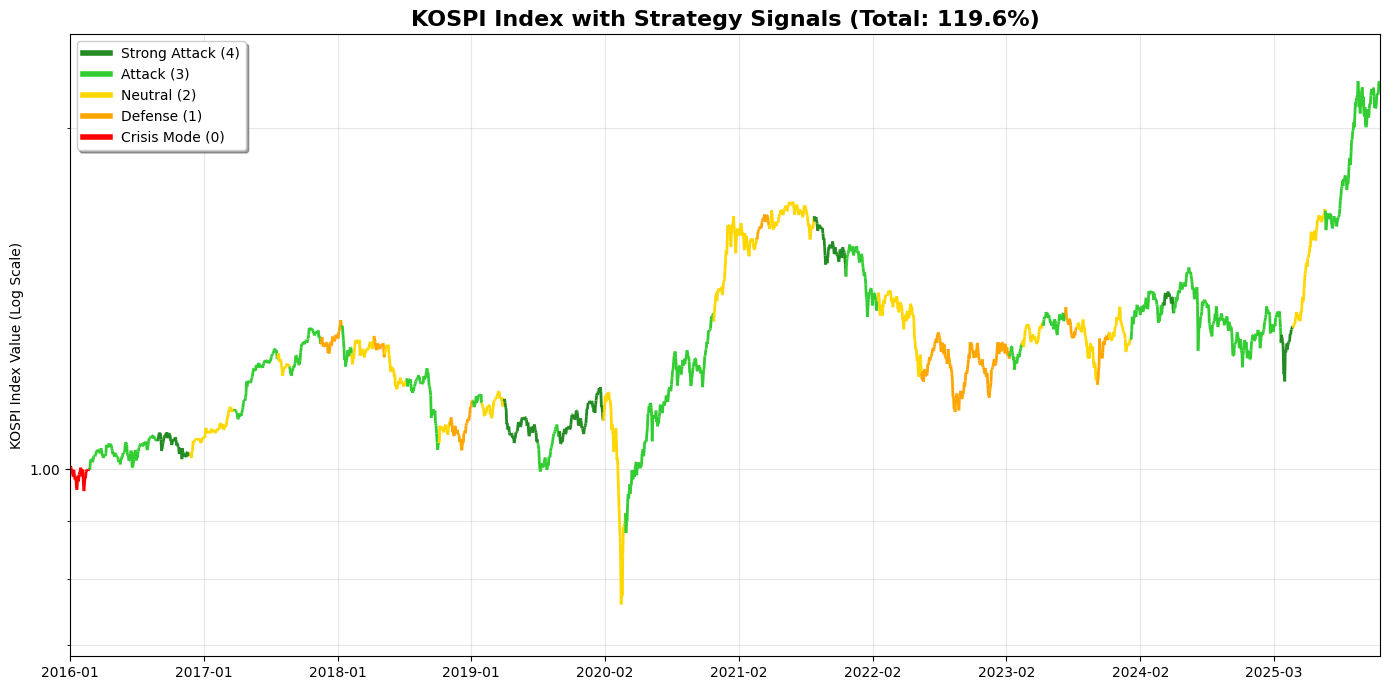


백테스트 완료.


In [220]:
if __name__ == "__main__":
    print("\n" + "="*50)
    print("전략 백테스트")
    print("="*50)

    # 1. 유니버스 로드
    univ = get_universe_from_csv()

    if univ:
        # 2. 각 전략 계산
        agg_ret = calculate_aggressive_strategy(univ)
        def_ret = calculate_defensive_strategy()
        canary = get_historical_canary_signals()

        # 3. 백테스트 실행
        if not agg_ret.empty and not def_ret.empty and canary is not None:
            port_ret, weights = run_backtest(agg_ret, def_ret, canary)

            # 4. 결과 출력
            evaluate_performance(port_ret)
            plot_canary_visualization(port_ret, canary)
            print("\n백테스트 완료.")
        else:
            print("데이터 부족으로 중단되었습니다.")